Dataset Shape: (3162, 447)

MODEL COMPARISON
           Model  Accuracy  Weighted F1  CV Score
0  Random Forest  0.947867     0.946237  0.942832
1    Extra Trees  0.946288     0.941548  0.928766
2        XGBoost  0.968404     0.967692  0.949489


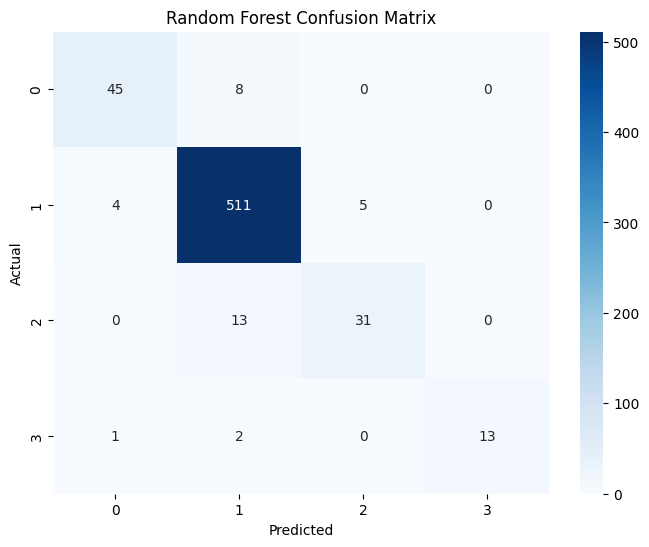

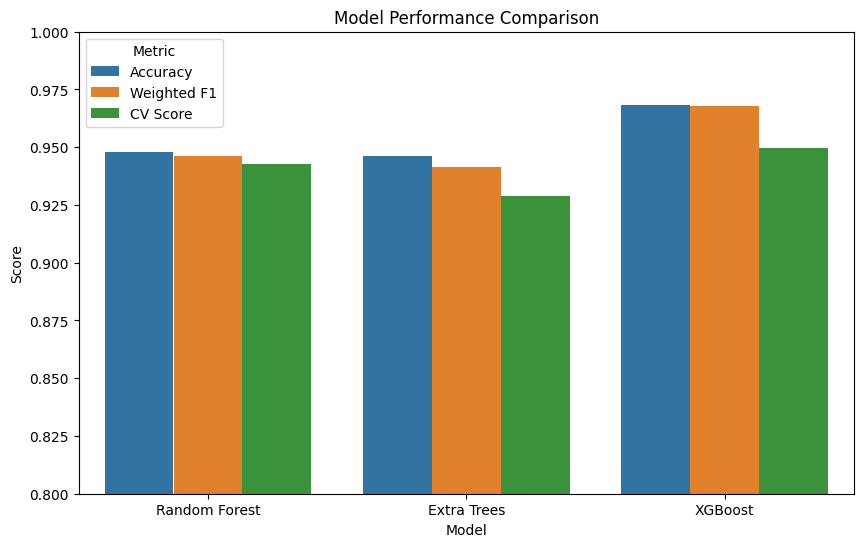


CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.90      0.85      0.87        53
           1       0.96      0.98      0.97       520
           2       0.86      0.70      0.78        44
           3       1.00      0.81      0.90        16

    accuracy                           0.95       633
   macro avg       0.93      0.84      0.88       633
weighted avg       0.95      0.95      0.95       633


Best model saved successfully!


In [4]:
# ============================================================
# KERATOCONUS DETECTION - CLEAN IEEE STYLE PIPELINE
# WITH ESSENTIAL VISUALIZATIONS ONLY
# ============================================================

# ============================================================
# IMPORTS
# ============================================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_val_score
)

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

from sklearn.pipeline import Pipeline

from sklearn.feature_selection import SelectFromModel
from sklearn.decomposition import PCA

from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier
)

from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    confusion_matrix,
    classification_report
)

import warnings
warnings.filterwarnings("ignore")

# ============================================================
# LOAD DATA
# ============================================================

data = pd.read_csv('/content/dataset.csv')
labels = pd.read_csv('/content/labels.csv')

# ============================================================
# MERGE DATA
# ============================================================

merged = pd.concat([data, labels], axis=1)

# ============================================================
# FEATURES + TARGET
# ============================================================

y = merged['clster_labels'] - 1 # Adjust labels to be 0-indexed

X = merged.drop(columns=['clster_labels'])

# Keep numeric columns only
X = X.select_dtypes(include=[np.number])

print("Dataset Shape:", X.shape)

# ============================================================
# TRAIN TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# ============================================================
# COMMON PREPROCESSING PIPELINE
# ============================================================

preprocessing = Pipeline([

    (
        'imputer',
        SimpleImputer(strategy='median')
    ),

    (
        'scaler',
        StandardScaler()
    ),

    (
        'feature_selection',
        SelectFromModel(
            ExtraTreesClassifier(
                n_estimators=100,
                random_state=42
            )
        )
    ),

    (
        'pca',
        PCA(
            n_components=0.95,
            random_state=42
        )
    )
])

# ============================================================
# MODELS
# ============================================================

models = {

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        max_depth=15,
        min_samples_split=5,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ),

    "Extra Trees": ExtraTreesClassifier(
        n_estimators=200,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ),

    "XGBoost": XGBClassifier(
        n_estimators=150,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric='mlogloss',
        random_state=42
    )
}

# ============================================================
# MODEL COMPARISON
# ============================================================

results = []

for name, model in models.items():

    # Full Pipeline
    pipeline = Pipeline([
        ('preprocessing', preprocessing),
        ('classifier', model)
    ])

    # Train
    pipeline.fit(X_train, y_train)

    # Predict
    y_pred = pipeline.predict(X_test)

    # Metrics
    accuracy = accuracy_score(y_test, y_pred)

    f1 = f1_score(
        y_test,
        y_pred,
        average='weighted'
    )

    # Cross Validation
    cv = StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=42
    )

    cv_score = cross_val_score(
        pipeline,
        X,
        y,
        cv=cv,
        scoring='f1_weighted',
        n_jobs=-1
    ).mean()

    # Save Results
    results.append([
        name,
        accuracy,
        f1,
        cv_score
    ])

    # Save Random Forest Confusion Matrix
    if name == "Random Forest":

        best_pipeline = pipeline
        best_predictions = y_pred

# ============================================================
# RESULTS TABLE
# ============================================================

results_df = pd.DataFrame(
    results,
    columns=[
        'Model',
        'Accuracy',
        'Weighted F1',
        'CV Score'
    ]
)

print("\n==============================")
print("MODEL COMPARISON")
print("==============================")

print(results_df)

# ============================================================
# VISUALIZATION 1 - CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(
    y_test,
    best_predictions
)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title('Random Forest Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

# ============================================================
# VISUALIZATION 2 - MODEL COMPARISON GRAPH
# ============================================================

results_melted = results_df.melt(
    id_vars='Model',
    value_vars=[
        'Accuracy',
        'Weighted F1',
        'CV Score'
    ],
    var_name='Metric',
    value_name='Score'
)

plt.figure(figsize=(10,6))

sns.barplot(
    data=results_melted,
    x='Model',
    y='Score',
    hue='Metric'
)

plt.ylim(0.8, 1.0)

plt.title('Model Performance Comparison')

plt.show()

# ============================================================
# CLASSIFICATION REPORT
# ============================================================

print("\n==============================")
print("CLASSIFICATION REPORT")
print("==============================")

print(
    classification_report(
        y_test,
        best_predictions
    )
)

# ============================================================
# SAVE BEST MODEL
# ============================================================

import joblib

joblib.dump(
    best_pipeline,
    'keratoconus_best_model.pkl'
)

print("\nBest model saved successfully!")